In [50]:
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [51]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

In [52]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [53]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [54]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [55]:
class State(TypedDict):
    question: str
    need_retrieval: bool
    docs: list[Document]
    relevant_docs: list[Document]
    answer: str
    context: str

    issup: Literal["fully_supported","partially_supported","no_support"]

    retries: int

    isuse: Literal["useful","not_useful"]
    use_reason: str

    retrieval_query: str
    rewrite_tries: int

In [56]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."""
        ),
        ("human", "Question: {question}"),
    ]
)


should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

decision_chain = decide_retrieval_prompt | should_retrieve_llm

def decide_retrieval(state: "State"):
    # decision: RetrieveDecision = should_retrieve_llm.invoke(
    #     decide_retrieval_prompt.format_messages(question=state["question"])
    # )
    decision: RetrieveDecision = decision_chain.invoke({"question":state["question"]})
    return {"need_retrieval": decision.should_retrieve}

In [57]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"""
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }

In [58]:
def retrieve(state: State):
    q = state.get("retrieval_query") or state["question"]
    return {"docs": retriever.invoke(q)}

In [59]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(...,description="True if the document helps answer the question, else False")

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        ('system',
         """You are judging document relevance.
         Return JSON that matches this schema: {{'is_relevant':boolean}}
         A document is relevant if it contains information useful for answering the question"""
        ),
        (
            "human",
            "Question: \n{question}\n\nDocument:\n{document}"
        )
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs = []

    chain = is_relevant_prompt | relevance_llm

    for doc in state["docs"]:
        decision = chain.invoke({"question":state["question"],"document":doc})
        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs":relevant_docs}

In [60]:
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a bussiness RAG assistant.
            Answer the user's question using ONLY the provided context.
            If the context does not contain enough information, say: No relevant document found
            Do not use outside knowledge."""
        ),
        ("human",
         """Question:{question}\n
         Context: {context}"""
        )
    ]
)

def generate_from_context(state: State):
    context = "\n".join([d.page_content for d in state.get("relevant_docs",[])]).strip()

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )

    return {"answer":out.content, "context": context}

def no_answer_found(state: State):
    return {"answer": "No answer found.", "context": ""}

In [61]:
def no_relevant_docs(state: State):
    return {"answer":"No relevant documents found.", "context":""}

In [62]:
class IsSupDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]


issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Do not use outside knowledge."""
        ),
        (
            "human",
            "Question:\n{question}\n\n Answer:\n{answer}\n\n Context:\n{context}\n"  
        ),
    ]
)



issup_llm = llm.with_structured_output(IsSupDecision)

def is_sup(state: State):
    decision: IsSupDecision = issup_llm.invoke(
        issup_prompt.format_messages(
            question = state["question"],
            answer=state.get("answer",""),
            context=state.get("context","")
        )
    )

    return {"issup":decision.issup}

MAX_RETRIES = 10

def route_after_issup(state: State) -> Literal["accept_answer", "revise_answer"]:

    if state.get("issup") == "fully_supported":
        return "accept_answer"

    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"

    return "revise_answer"

In [63]:
revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"""
        ),
        (
            "human",
            "Question:\n{question}\n\n Answer:\n{answer}\n\n Context:\n{context}\n" 
        ),
    ]
)



def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
            context=state.get("context", ""),
        )
    )
    return {
        "answer": out.content,
        "retries": state.get("retries", 0) + 1,
    }

In [65]:
class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: str = Field(...,description="Short reason in 1 line.")

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."""
        ),
        (
            "human",
            "Question:\n{question}\n\nAnswer:\n{answer}"
        ),
    ]
)

isuse_llm = llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_llm.invoke(
        isuse_prompt.format_messages(
            question=state["question"],
            answer=state.get("answer", ""),
        )
    )
    return {"isuse": decision.isuse, "use_reason": decision.reason}

MAX_REWRITE_TRIES = 3  # tune (2–4 is usually fine)

def route_after_isuse(state: State) -> Literal["END", "rewrite_question", "no_answer_found"]:
    if state.get("isuse") == "useful":
        return "END"

    if state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "no_answer_found"

    return "rewrite_question"

In [66]:
class RewriteDecision(BaseModel):
    retrieval_query: str = Field(
        ...,
        description="Rewritten query optimized for vector retrieval against internal company PDFs."
    )

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6–16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2–5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"""
        ),
        (
            "human",
            """QUESTION:\n{question}\n\n
            Previous retrieval query:\n{retrieval_query}\n\n
            Answer (if any):\n{answer}"""
        ),
    ]
)



rewrite_llm = llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_llm.invoke(
        rewrite_for_retrieval_prompt.format_messages(
            question=state["question"],
            retrieval_query=state.get("retrieval_query", ""),
            answer=state.get("answer", ""),
        )
    )

    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": state.get("rewrite_tries", 0) + 1,
        "docs": [],
        "relevant_docs": [],
        "context": "",
    }

In [67]:
def route_after_decide(state: State) -> Literal["generate_direct","retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"

    return "generate_direct"

In [68]:
def route_after_relevance(state: State) -> Literal["generate_from_context","no_answer_found"]:
    if state.get("relevant_docs") and len(state["relevant_docs"])>0:
        return "generate_from_context"
    return "no_answer_found"

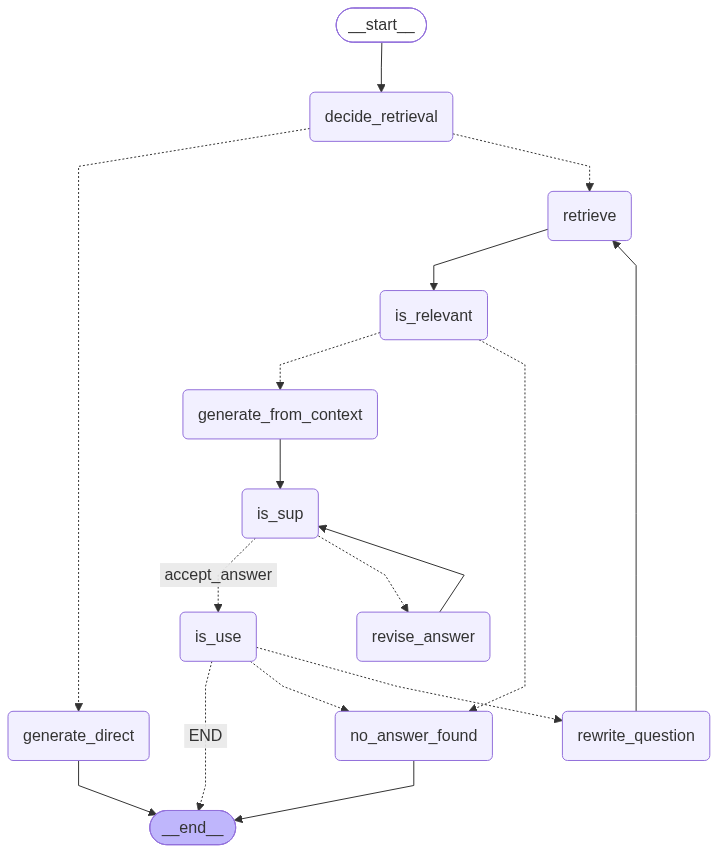

In [70]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct",generate_direct)
g.add_node("retrieve",retrieve)
g.add_node("is_relevant",is_relevant)
g.add_node("generate_from_context",generate_from_context)
g.add_node("no_answer_found", no_answer_found)
g.add_node("is_use", is_use)
g.add_node("is_sup",is_sup)
g.add_node("revise_answer", revise_answer)
g.add_node("rewrite_question", rewrite_question)

g.add_edge(START,"decide_retrieval")
g.add_conditional_edges("decide_retrieval", route_after_decide, {"generate_direct":"generate_direct","retrieve":"retrieve"})
g.add_edge("retrieve","is_relevant")
g.add_conditional_edges("is_relevant",route_after_relevance,{"generate_from_context":"generate_from_context","no_answer_found":"no_answer_found"})
g.add_edge("generate_direct",END)
g.add_edge("generate_from_context","is_sup")

g.add_edge("revise_answer", "is_sup")
g.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",
        "revise_answer": "revise_answer",
    },
)
g.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "END": END,
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_answer_found",
    },
)

g.add_edge("rewrite_question", "retrieve")


app = g.compile()

app

In [ ]:
result = app.invoke({
    "question":"What is the refund policy of NenaxAI",
    "answer":""
})

print("need_retrieval:",result["need_retrieval"])
print("docs:",len(result["docs"]))
print("relavent_docs:",len(result["relevant_docs"]))
print("issup:",result["issup"])
print("retries: ", result["retries"])
print("issup:",result["isuse"])
print("answer:",result["answer"])

need_retrieval: True
docs: 4
relavent_docs: 1
issup: fully_supported
retries:  1
issup: useful
answer: - "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


1